# SVM Project — Wine Fraud Detection

**Задача**: По химическим характеристикам вина (pH, кислотность, алкоголь и др.) определить, является ли вино легальным (Legit) или поддельным (Fraud).

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Загрузка данных

In [2]:
df = pd.read_csv("wine_fraud.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   str    
 12  type                  6497 non-null   str    
dtypes: float64(11), str(2)
memory usage: 660.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


## 2. EDA — Исследовательский анализ данных

**Задание: посмотрим на распределение признаков по столбцу quality (Legit/Fraud)**

In [5]:
df["quality"].value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

In [6]:
# Сильный дисбаланс классов — мошеннических вин намного меньше
df["quality"].value_counts(normalize=True)

quality
Legit    0.962136
Fraud    0.037864
Name: proportion, dtype: float64

**Countplot: количество Legit и Fraud**

C:\Users\baika\AppData\Local\Temp\ipykernel_2196\2234665945.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="Set2")


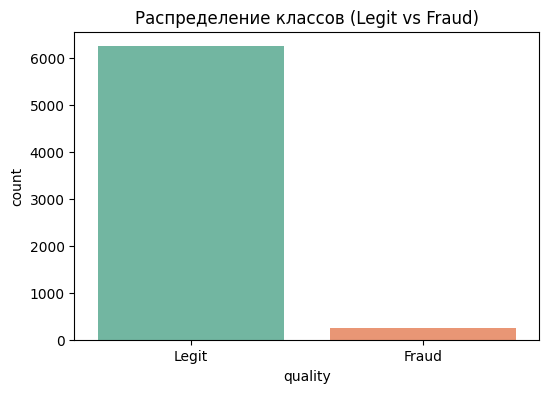

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df, palette="Set2")
plt.title("Распределение классов (Legit vs Fraud)")
plt.show()

**Countplot: количество Legit/Fraud по типу вина (red/white)**

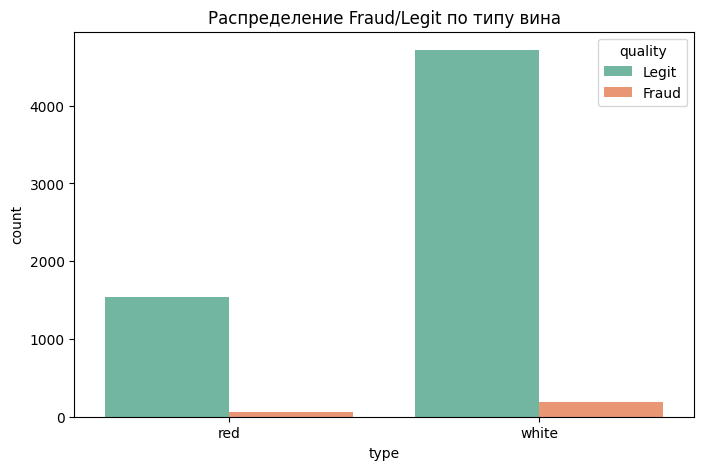

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=df, hue="quality", palette="Set2")
plt.title("Распределение Fraud/Legit по типу вина")
plt.show()

**Какие признаки больше всего отличаются между классами?**

C:\Users\baika\AppData\Local\Temp\ipykernel_2196\3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
C:\Users\baika\AppData\Local\Temp\ipykernel_2196\3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")


C:\Users\baika\AppData\Local\Temp\ipykernel_2196\3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
C:\Users\baika\AppData\Local\Temp\ipykernel_2196\3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
C:\Users\baika\AppData\Local\Temp\ipykernel_2196\3122152949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
C:\Users\baika\AppData\Local\Temp\ipykernel_2196\312

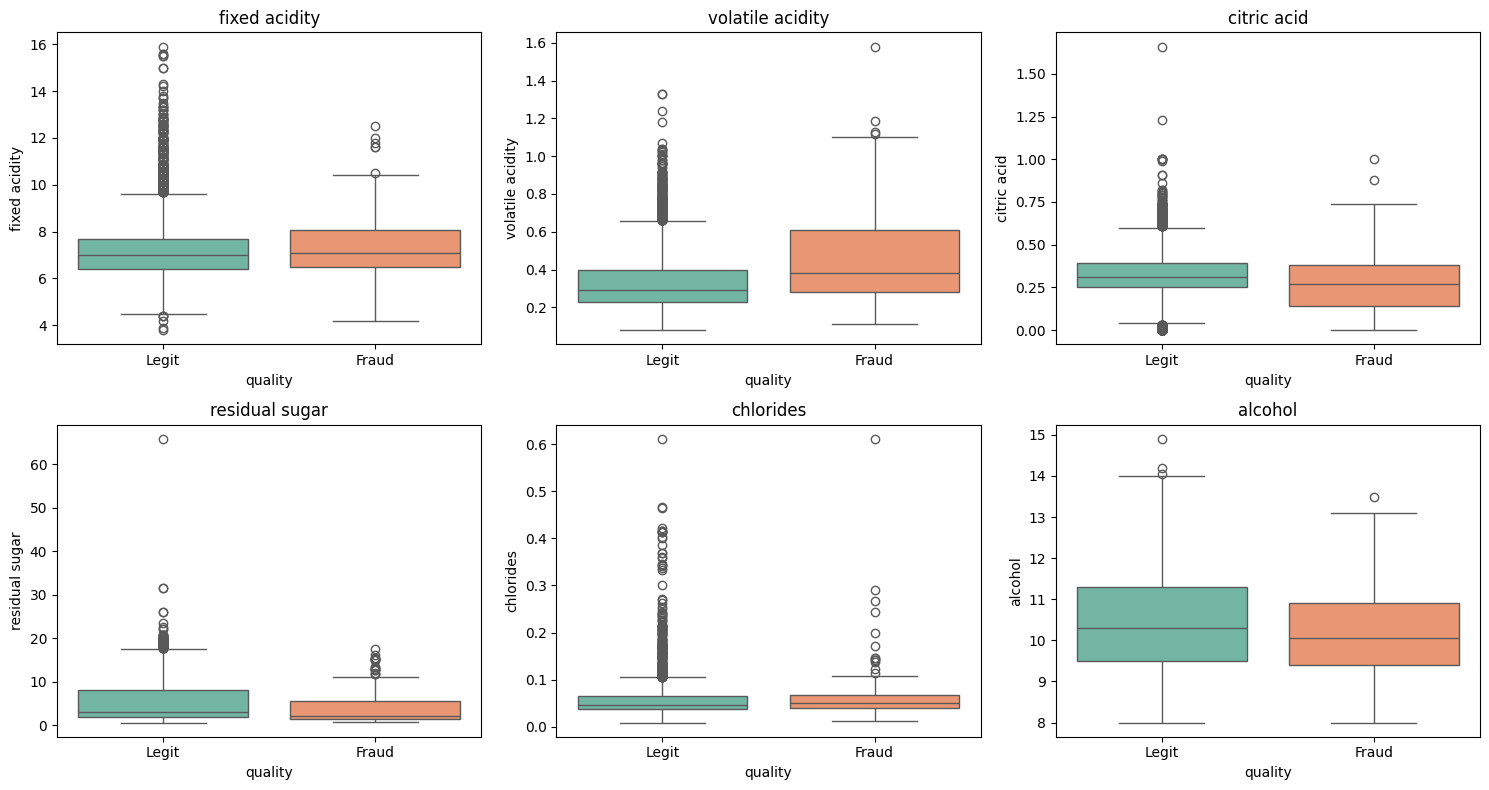

In [9]:
# Boxplot ключевых признаков по классу
features = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
            "chlorides", "alcohol"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x="quality", y=feat, data=df, ax=ax, palette="Set2")
    ax.set_title(feat)
plt.tight_layout()
plt.show()

In [10]:
# Средние значения признаков по классу
df.groupby("quality").mean(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
Fraud,7.357724,0.465163,0.273374,4.273984,0.062126,22.902439,105.701220,0.994944,3.234797,0.505732,10.18435
Legit,7.209702,0.334727,0.320414,5.489250,0.055794,30.825308,116.139818,0.994687,3.217860,0.532273,10.50390


**Корреляция числовых признаков с целевой переменной**

Преобразуем quality в 0/1 для подсчёта корреляций.

In [11]:
df_corr = df.copy()
df_corr["quality_num"] = (df_corr["quality"] == "Fraud").astype(int)
corr = df_corr.drop(columns=["quality","type"]).corr()[["quality_num"]].sort_values("quality_num", ascending=False)
print(corr)

                      quality_num
quality_num              1.000000
volatile acidity         0.151228
chlorides                0.034499
fixed acidity            0.021794
pH                       0.020107
density                  0.016351
sulphates               -0.034046
total sulfur dioxide    -0.035252
residual sugar          -0.048756
alcohol                 -0.051141
citric acid             -0.061789
free sulfur dioxide     -0.085204


**Bar plot корреляций признаков с целевой переменной**

<Figure size 800x500 with 0 Axes>

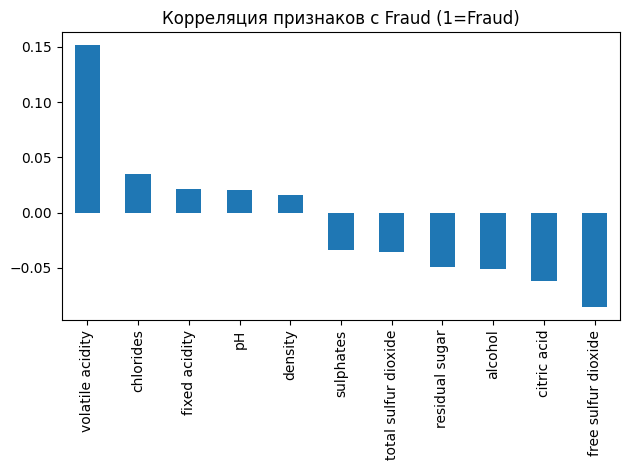

In [12]:
plt.figure(figsize=(8,5))
corr.drop("quality_num").plot(kind="bar", legend=False)
plt.title("Корреляция признаков с Fraud (1=Fraud)")
plt.tight_layout()
plt.show()

**Clustermap для визуализации корреляций между всеми признаками**

<Figure size 640x480 with 0 Axes>

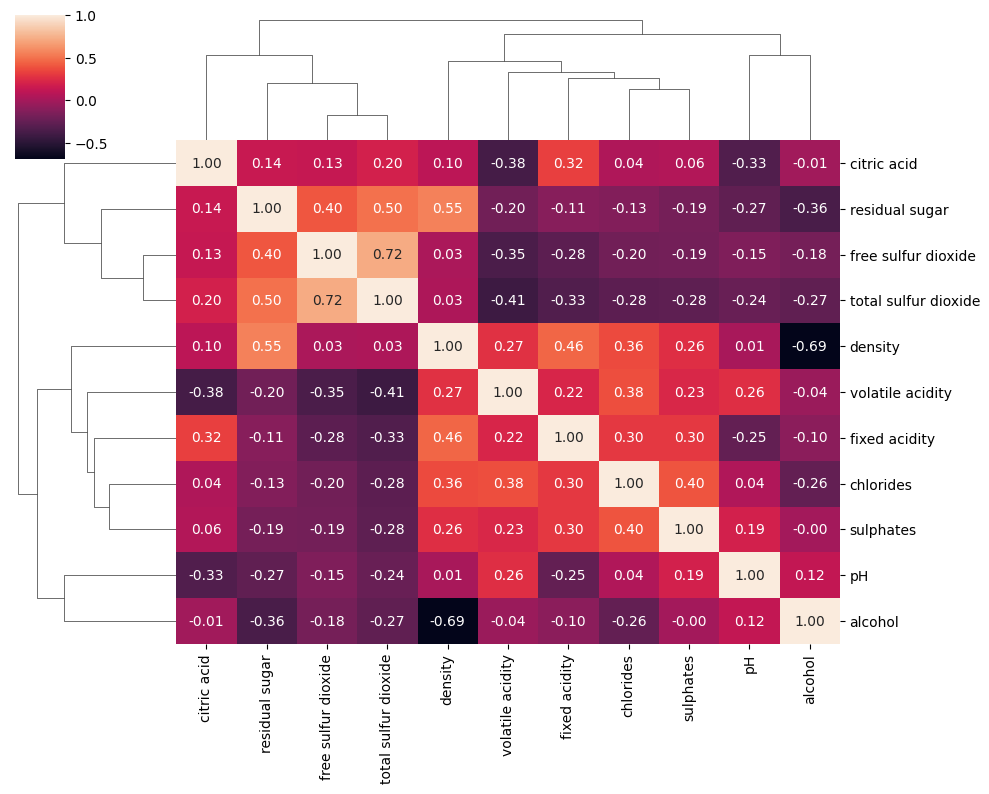

In [13]:
plt.figure()
sns.clustermap(df.drop(columns=["quality","type"]).corr(), annot=True, fmt=".2f", figsize=(10,8))
plt.show()

---
## 3. Предобработка данных

**Преобразуем колонку "type" (red/white) в dummy-переменные**

In [14]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,False
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,False
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,False
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,False
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,False


**Формируем X (признаки) и y (целевая переменная — quality)**

In [15]:
X = df.drop(columns=["quality"])
y = df["quality"]

**Разбивка на train/test: 90% / 10%, random_state=101**

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=101)

**Масштабирование данных с помощью StandardScaler**

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

---
## 4. Обучение базовой модели SVM

**Обучаем SVC с параметрами по умолчанию**

In [18]:
from sklearn.svm import SVC
# Параметры по умолчанию: kernel=rbf, C=1.0, gamma=scale
svc_base = SVC()
svc_base.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
y_pred_base = svc_base.predict(X_test)
print("=== Базовая модель SVC ===")
print(confusion_matrix(y_test, y_pred_base))
print()
print(classification_report(y_test, y_pred_base))

=== Базовая модель SVC ===
[[  0  27]
 [  0 623]]

              precision    recall  f1-score   support

       Fraud       0.00      0.00      0.00        27
       Legit       0.96      1.00      0.98       623

    accuracy                           0.96       650
   macro avg       0.48      0.50      0.49       650
weighted avg       0.92      0.96      0.94       650



C:\Users\baika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\baika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\baika\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

---
## 5. Подбор гиперпараметров через GridSearchCV

**GridSearchCV по параметрам C и gamma**

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [1, 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5, scoring="f1_macro")
grid.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s


[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s


[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.3s


[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.3s


[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.3s


[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.3s


[CV] END ...........................C=1, gamma=1, kernel=rbf; total time=   0.3s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.0s


[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   0.2s


[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   0.2s


[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   0.2s


[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   0.2s


[CV] END ..........................C=10, gamma=1, kernel=rbf; total time=   0.2s
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=   0.0s


[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END .......................C=10, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time=   0.0s
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END ......................C=10, gamma=0.001, kernel=rbf; total time=   0.0s


[CV] END .........................C=100, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=100, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=100, gamma=1, kernel=rbf; total time=   0.2s


[CV] END .........................C=100, gamma=1, kernel=rbf; total time=   0.3s


[CV] END .........................C=100, gamma=1, kernel=rbf; total time=   0.2s
[CV] END .......................C=100, gamma=0.1, kernel=rbf; total time=   0.1s


[CV] END .......................C=100, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .......................C=100, gamma=0.1, kernel=rbf; total time=   0.1s


[CV] END .......................C=100, gamma=0.1, kernel=rbf; total time=   0.1s
[CV] END .......................C=100, gamma=0.1, kernel=rbf; total time=   0.1s


[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.2s


[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.1s


[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.1s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s


[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.3s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s


[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s


[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold an

In [21]:
print("Лучшие параметры:", grid.best_params_)
print("Лучший score (cv):", round(grid.best_score_, 4))

Лучшие параметры: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Лучший score (cv): 0.6162


---
## 6. Оценка лучшей модели

In [22]:
y_pred_best = grid.predict(X_test)
print("=== Лучшая модель после GridSearchCV ===")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print()

=== Лучшая модель после GridSearchCV ===
[[  2  25]
 [  5 618]]



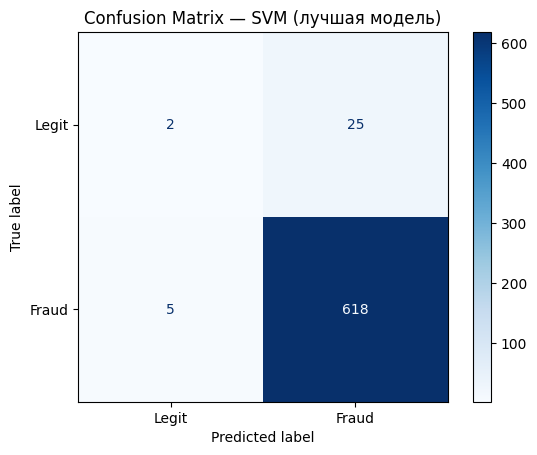

In [23]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — SVM (лучшая модель)")
plt.show()

In [24]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

       Fraud       0.29      0.07      0.12        27
       Legit       0.96      0.99      0.98       623

    accuracy                           0.95       650
   macro avg       0.62      0.53      0.55       650
weighted avg       0.93      0.95      0.94       650



---
## 7. Выводы

- **Дисбаланс классов**: Fraud встречается лишь в ~3.8% случаев — задача несбалансированная, поэтому accuracy не показательна, важны precision/recall для класса Fraud.
- **Базовая SVC** уже даёт высокий accuracy, но может плохо определять Fraud из-за дисбаланса.
- **GridSearchCV** подобрал оптимальные C и gamma, улучшив recall для Fraud.
- **Выводы по признакам**: volatile acidity и chlorides наиболее коррелируют с мошенничеством — поддельные вина чаще имеют аномальные значения этих показателей.